# Week 2 - Lesson 2 - Edge Detection

In this lecture, we will do a deep dive into edge detection with OpenCV using an example image of a road.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### 1. Read Image

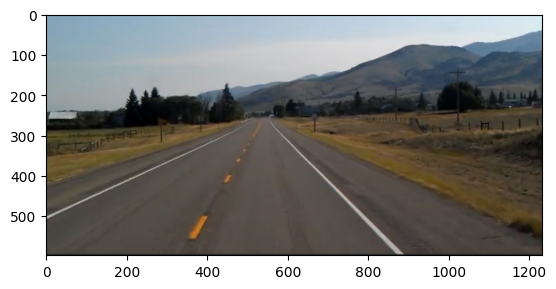

In [3]:
image = cv2.imread("test_image.jpg")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

### 2. Convert image to grayscale

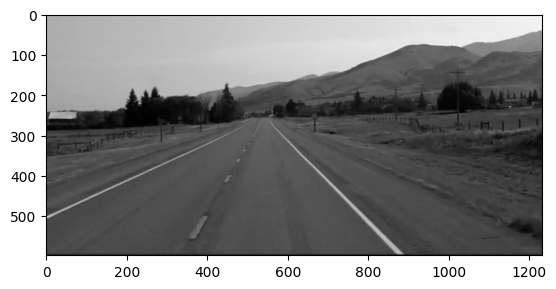

In [4]:
gray = cv2.cvtColor(image, cv2.COLOR_RGBA2GRAY)
plt.imshow(gray, cmap='gray')

### 3. Apply Gaussian Blur to image

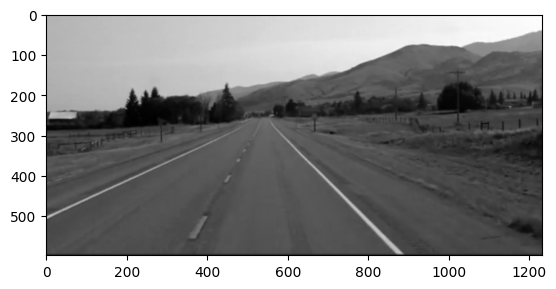

In [5]:
gaussian_blur = cv2.GaussianBlur(gray, (5, 5), 0)
plt.imshow(gaussian_blur, cmap='gray')

### 4. Applying Canny for Edge Detection on image

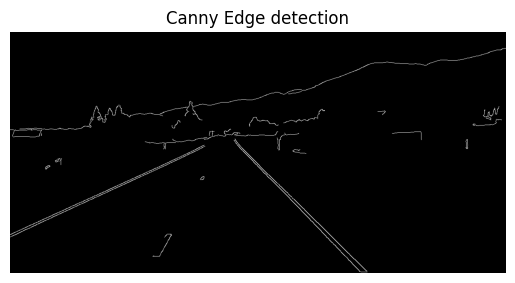

In [6]:
edges = cv2.Canny(gaussian_blur, 50, 150)

plt.imshow(edges, cmap='gray')
plt.title("Canny Edge detection")
plt.axis('off')
plt.show()

Using the ```Canny()``` method on images here is not enough to detect the lane lines only because other object edges are also in the geiven threshold range of (50, 150). So we have to use something called the **Region of Interest (RoI)** technique to focus to the lane only.

### 5. Region of Interest (RoI)

In [8]:
image.shape

(598, 1232, 3)

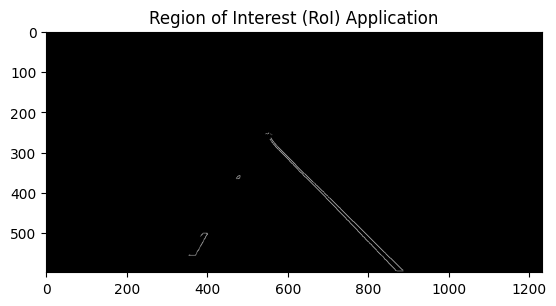

In [9]:
height = edges.shape[0] # Get the height of the image

roi = np.array([[(200, height), (1100, height), (550, 250)]])
mask = np.zeros_like(edges) # Create a mask with the same shape as the edges image

cv2.fillPoly(mask, [roi], 255) # Fill the polygon defined by the roi with white color

cropped_edges = cv2.bitwise_and(edges, mask) # Apply the mask to the edges image

plt.imshow(cropped_edges, cmap='gray')
plt.title("Region of Interest (RoI) Application")
plt.show()

Now, we are in the game. Finally we have a better result we can work with to detect lanes for self driving cars in real time video. But this is the beginning and a drop of water of the big ocean. We have to put more work and optimization into other images and videos of roads to have usable detection masks.